In [196]:
%reset -f

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({'font.size': 16})
import seaborn as sns
import matplotlib.dates as mdates
import nrarfcn as nr

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Map plotting imports
import geopandas as gpd
from bokeh.plotting import figure, show#, output_notebook
# output_notebook()
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar, HoverTool, WheelZoomTool, WMTSTileSource, Arrow, NormalHead
from bokeh.palettes import Viridis256, Bokeh
from bokeh.io import output_file
from bokeh.transform import factor_cmap
import random
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

In [197]:
def load_csv(name):
    # This enables loading CSVs and pd.to_datetime simultaneously
    return pd.read_csv(f"2026q3-ndCbrsCbandInterference/_data/{name}.csv", parse_dates=['Time'], low_memory=False)

# lteRadio = load_csv('lte_radio')
# ltePdsch = load_csv('lte_pdsch')
# ltePusch = load_csv('lte_pusch')
nrRadio = load_csv('nr_radio')
# nrRadioBeam = load_csv('nr_radio_beam')
nrPdsch = load_csv('nr_pdsch')
nrPusch = load_csv('nr_pusch')

In [198]:
collection_mask = lambda df: df['Collection'].str.startswith(('V_', 'C_'), na=False)

nrRadio = nrRadio.loc[collection_mask(nrRadio)]
nrPdsch = nrPdsch.loc[collection_mask(nrPdsch)]
nrPusch = nrPusch.loc[collection_mask(nrPusch)]

In [217]:
nrRadio.loc[
    nrRadio['Collection'].str.startswith('C_', na=False),
    # & (nrRadio['Cell Type'] == 'MCG PCell'),
    ['SSB NR-ARFCN', 'DL NR-ARFCN', 'UL NR-ARFCN', 'DL Bandwidth', 'UL Bandwidth','DL Bandwidth Aggregated', 'UL Bandwidth Aggregated']
].value_counts(dropna=False)

SSB NR-ARFCN  DL NR-ARFCN  UL NR-ARFCN  DL Bandwidth  UL Bandwidth  DL Bandwidth Aggregated  UL Bandwidth Aggregated
644544        644544       644544       40            40.0          40                       40                         22596
Name: count, dtype: int64

In [207]:
nrRadio.loc[
    nrRadio['Collection'].str.startswith('V_', na=False)
    & (nrRadio['Cell Type'] == 'MCG PCell'),
    ['SSB NR-ARFCN', 'DL NR-ARFCN', 'UL NR-ARFCN', 'DL Bandwidth', 'UL Bandwidth','DL Bandwidth Aggregated', 'UL Bandwidth Aggregated']
].value_counts(dropna=False)

SSB NR-ARFCN  DL NR-ARFCN  UL NR-ARFCN  DL Bandwidth  UL Bandwidth  DL Bandwidth Aggregated  UL Bandwidth Aggregated
647328        647328       647328       100           100.0         200                      100                        15289
                                                                    100                      100                         2655
Name: count, dtype: int64

In [212]:
nrPdsch.loc[
    nrPdsch['Collection'].str.startswith('V_', na=False),
    # & (nrPdsch['Cell Type'] == 'MCG PCell'),
    ['PCI 5G NR', 'Cell Type', 'DL NR-ARFCN', 'DL Bandwidth', 'DL Bandwidth Aggregated']
].value_counts(dropna=False)

PCI 5G NR  Cell Type   DL NR-ARFCN  DL Bandwidth  DL Bandwidth Aggregated
822        MCG PCell   647328       100           100                        10419
                                                  200                         5622
863        MCG SCell1  653952       100           200                         3633
822        MCG SCell1  653952       100           200                         1989
Name: count, dtype: int64

In [214]:
nrPusch.loc[
    nrPusch['Collection'].str.startswith('V_', na=False),
    # & (nrPusch['Cell Type'] == 'MCG PCell'),
    ['PCI 5G NR', 'Cell Type', 'UL NR-ARFCN', 'UL Bandwidth', 'UL Bandwidth Aggregated']
].value_counts(dropna=False)

PCI 5G NR  Cell Type  UL NR-ARFCN  UL Bandwidth  UL Bandwidth Aggregated
822        MCG PCell  647328       100           100                        15899
Name: count, dtype: int64

In [126]:
def plot_geo_scatter_map(df, value_col, title="Geo Map", colorbar_title="Value", unit="", value_range=[-140, -60], dir_arrow=False):

    if 'latitude' in df.columns:
        df.rename(columns={'latitude': 'Latitude'}, inplace=True)
    if 'longitude' in df.columns:
        df.rename(columns={'longitude': 'Longitude'}, inplace=True)

    # Create GeoDataFrame and project to Web Mercator
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs="EPSG:4326").to_crs("EPSG:3857")
    gdf['x'], gdf['y'] = gdf.geometry.x, gdf.geometry.y

    # Setup Bokeh figure
    p = figure(
        title=title, width=800, height=500,
        x_axis_type="mercator", y_axis_type="mercator",
        tools="pan,reset,save",
        x_range=(gdf['x'].min()-100, gdf['x'].max()+100),
        y_range=(gdf['y'].min()-100, gdf['y'].max()+100)
    )
    p.add_tools(WheelZoomTool(zoom_on_axis=False))
    p.add_tile(WMTSTileSource(
        url='https://cartodb-basemaps-4.global.ssl.fastly.net/light_all/{Z}/{X}/{Y}.png',
        attribution="© CartoDB contributors")
    )

    # Color mapping and data source
    # color_mapper = LinearColorMapper(palette=Bokeh[8], low=gdf[value_col].min(), high=gdf[value_col].max())
    color_mapper = LinearColorMapper(palette=Bokeh[8], low=value_range[0], high=value_range[1])
    # color_mapper = LinearColorMapper(palette=Viridis256, low=-160, high=-40)
    source = ColumnDataSource(gdf[['x', 'y', value_col, 'Latitude', 'Longitude']])

    # Scatter points
    p.scatter(
        x='x', y='y', size=5, source=source,
        fill_color={'field': value_col, 'transform': color_mapper},
        line_color=None, fill_alpha=0.7
    )

    # Walking-direction arrows adjacent to the measurements
    if dir_arrow and len(gdf) > 1:
        arrow_step = max(1, len(gdf) // 20)
        map_width = gdf['x'].max() - gdf['x'].min()
        map_height = gdf['y'].max() - gdf['y'].min()
        arrow_offset = max(map_width, map_height) * 0.05  # distance from measurements in Web Mercator meters

        for start_index in range(0, len(gdf) - 1, arrow_step):
            end_index = min(start_index + arrow_step, len(gdf) - 1)

            x_start = gdf['x'].iloc[start_index]
            y_start = gdf['y'].iloc[start_index]
            x_end = gdf['x'].iloc[end_index]
            y_end = gdf['y'].iloc[end_index]

            delta_x = x_end - x_start
            delta_y = y_end - y_start
            segment_length = np.sqrt(delta_x**2 + delta_y**2)

            if segment_length == 0:
                continue

            offset_x = -delta_y / segment_length * arrow_offset
            offset_y = delta_x / segment_length * arrow_offset

            p.add_layout(Arrow(
                end=NormalHead(size=8, fill_color="black", line_color="black"),
                x_start=x_start + offset_x, y_start=y_start + offset_y,
                x_end=x_end + offset_x, y_end=y_end + offset_y,
                line_color="black", line_width=1.5
            ))

    # Color bar and hover
    p.add_layout(ColorBar(color_mapper=color_mapper, label_standoff=12, location=(0,0), title=colorbar_title), 'right')
    p.add_tools(HoverTool(tooltips=[
        ("Lat/Lon", "@{Latitude}, @{Longitude}"),
        (value_col, f"@{{{value_col}}} {unit}")
    ]))

    ### Adding a red cross
    # cross_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy([-86.229485], [41.695861]), crs="EPSG:4326").to_crs("EPSG:3857")
    # p.scatter(x=cross_gdf.geometry.x[0], y=cross_gdf.geometry.y[0], size=15, marker="cross", color='red', line_width=3)

    p.toolbar.active_drag = None
    p.toolbar.active_inspect = None

    # output_file("bokeh_plot.html")
    show(p)

In [127]:
def plot_throughput_cdf(collection_range, figure_title=None):
    start, end = map(int, collection_range.split('-'))
    collections = [f'{number:03d}' for number in range(start, end + 1)]

    plot_configurations = [
        ('n48 DL', 'C', nrPdsch, '5G NR Net PDSCH Throughput', [(1, 'n77 idle'), (6, 'n77 DL'), (4, 'n77 UL')]),
        ('n48 UL', 'C', nrPusch, '5G NR Net PUSCH Throughput', [(0, 'n77 idle'), (5, 'n77 DL'), (7, 'n77 UL')]),
        ('n77 DL', 'V', nrPdsch, '5G NR Net PDSCH Throughput', [(3, 'n48 idle'), (6, 'n48 DL'), (5, 'n48 UL')]),
        ('n77 UL', 'V', nrPusch, '5G NR Net PUSCH Throughput', [(2, 'n48 idle'), (4, 'n48 DL'), (7, 'n48 UL')])
    ]

    colors = {'idle': 'gray', 'DL': 'tab:blue', 'UL': 'tab:red'}
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.ravel()

    if figure_title:
        fig.suptitle(figure_title, fontsize=17, fontweight="bold", y=0.925)

    for ax, (title, prefix, dataframe, column, experiments) in zip(axes, plot_configurations):
        for index, label in experiments:
            collection = f'{prefix}_{collections[index]}'
            mask = dataframe['Collection'] == collection

            if title == 'n77 DL':
                mask &= dataframe['DL NR-ARFCN'] == 647328

            df_temp = dataframe.loc[mask, column].dropna().sort_values() / 1e3
            state = label.split()[-1]

            if df_temp.shape[0] == 0:
                continue

            ax.plot(
                df_temp, np.linspace(0, 1, df_temp.shape[0]),
                label=rf"under {label} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
                linewidth=2, linestyle="solid", color=colors[state]
            )

        ax.set_title(title, fontsize=15, fontweight="bold")
        ax.set_xlabel("Throughput [Mbps]", fontsize=15, fontweight="bold")
        ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 325 if title == 'n48 DL' else 700 if title == 'n77 DL' else 100)
        ax.yaxis.set_minor_locator(AutoLocator())
        ax.grid(True, linestyle="--", which="both", axis="both")
        ax.tick_params(axis="both", labelsize=12)
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

In [128]:
def plot_sinr_cdf(collection_range, figure_title=None):
    start, end = map(int, collection_range.split('-'))
    collections = [f'{number:03d}' for number in range(start, end + 1)]

    plot_configurations = [
        ('n48 DL', 'C', [(1, 'n77 idle'), (6, 'n77 DL'), (4, 'n77 UL')]),
        ('n48 UL', 'C', [(0, 'n77 idle'), (5, 'n77 DL'), (7, 'n77 UL')]),
        ('n77 DL', 'V', [(3, 'n48 idle'), (6, 'n48 DL'), (5, 'n48 UL')]),
        ('n77 UL', 'V', [(2, 'n48 idle'), (4, 'n48 DL'), (7, 'n48 UL')])
    ]

    colors = {'idle': 'gray', 'DL': 'tab:blue', 'UL': 'tab:red'}
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.ravel()

    if figure_title:
        fig.suptitle(figure_title, fontsize=17, fontweight="bold", y=0.925)

    for ax, (title, prefix, experiments) in zip(axes, plot_configurations):
        for index, label in experiments:
            collection = f'{prefix}_{collections[index]}'
            mask = nrRadio['Collection'] == collection

            if title == 'n77 DL':
                mask &= nrRadio['DL NR-ARFCN'] == 647328

            df_temp = nrRadio.loc[mask, 'SS-SINR'].dropna().sort_values()
            state = label.split()[-1]

            if df_temp.shape[0] == 0:
                continue

            ax.plot(
                df_temp, np.linspace(0, 1, df_temp.shape[0]),
                label=rf"under {label} ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
                linewidth=2, linestyle="solid", color=colors[state]
            )

        ax.set_title(title, fontsize=15, fontweight="bold")
        ax.set_xlabel("SS-SINR [dB]", fontsize=15, fontweight="bold")
        ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
        ax.set_xlim(0, 40)
        ax.set_ylim(0, 1)
        ax.yaxis.set_minor_locator(AutoLocator())
        ax.grid(True, linestyle="--", which="both", axis="both")
        ax.tick_params(axis="both", labelsize=12)
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

# Throughtput

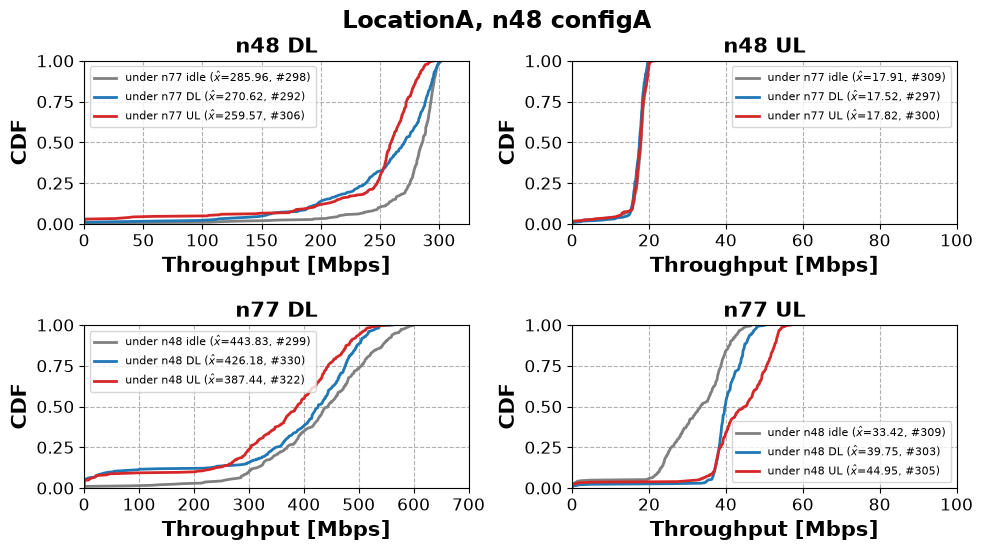

In [129]:
plot_throughput_cdf('004-012', 'LocationA, n48 configA')

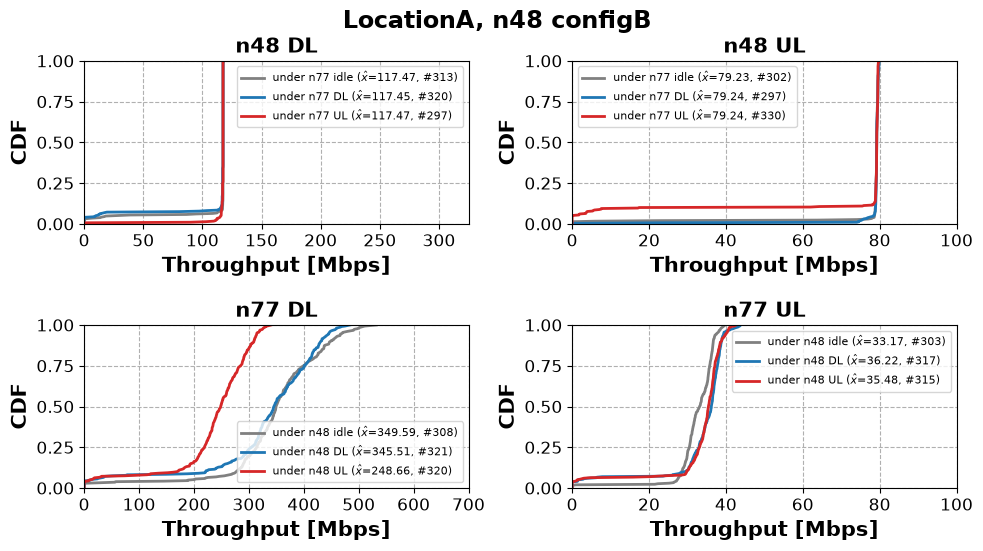

In [130]:
plot_throughput_cdf('049-057', 'LocationA, n48 configB')

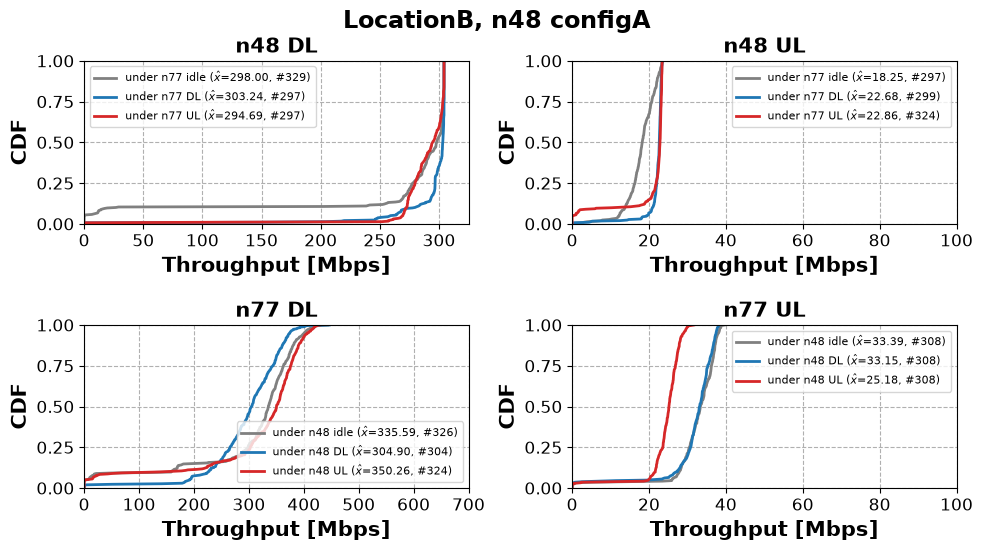

In [131]:
plot_throughput_cdf('013-021', 'LocationB, n48 configA')

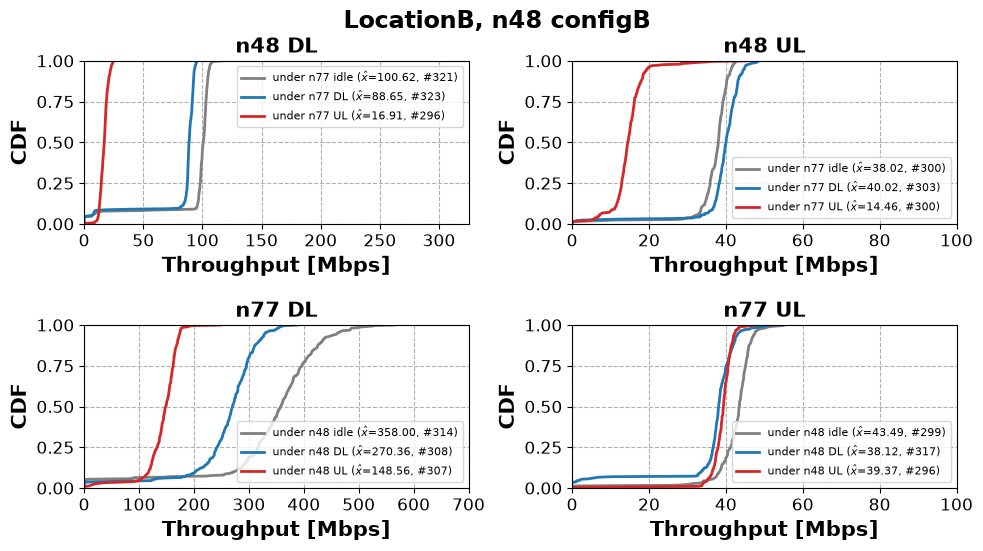

In [132]:
plot_throughput_cdf('058-066', 'LocationB, n48 configB')

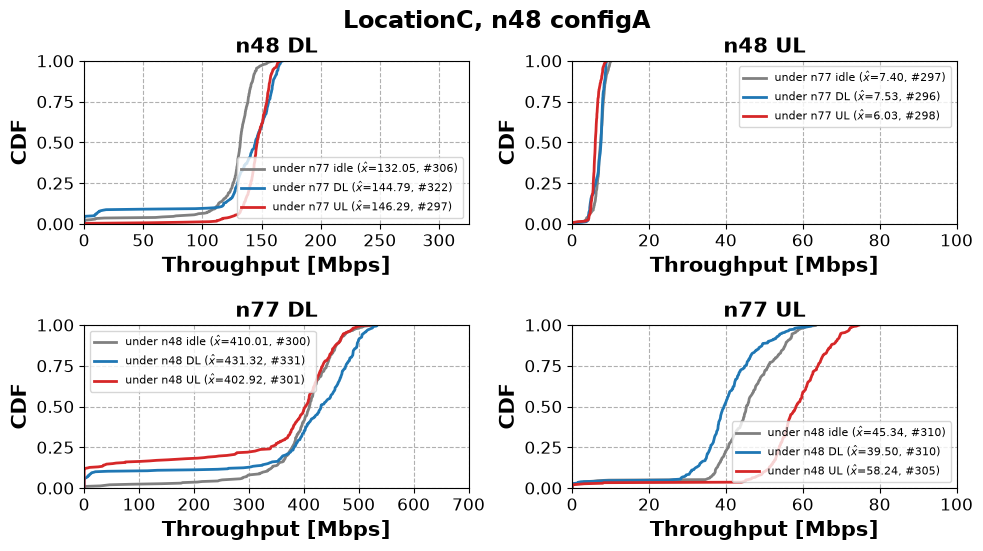

In [133]:
plot_throughput_cdf('022-030', 'LocationC, n48 configA')

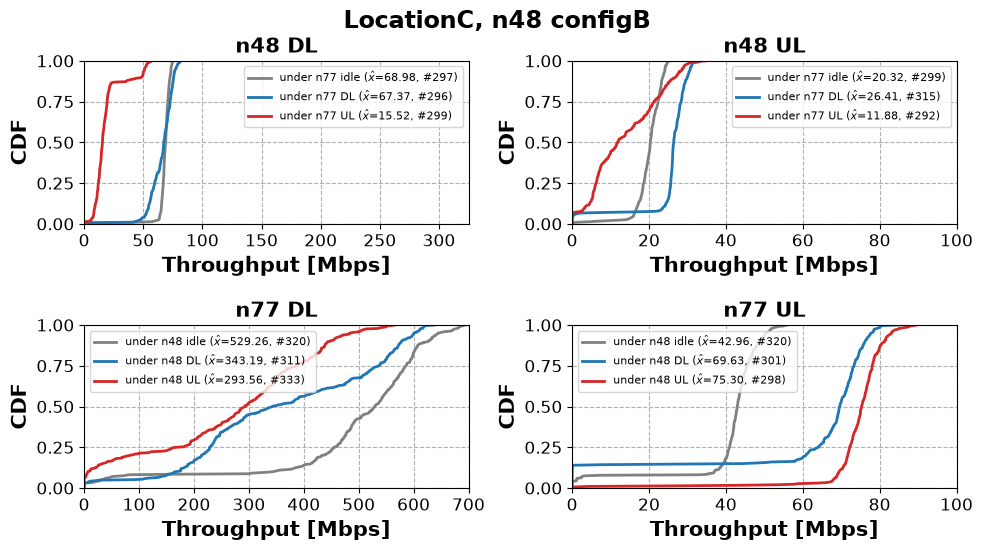

In [134]:
plot_throughput_cdf('067-075', 'LocationC, n48 configB')

# SINR

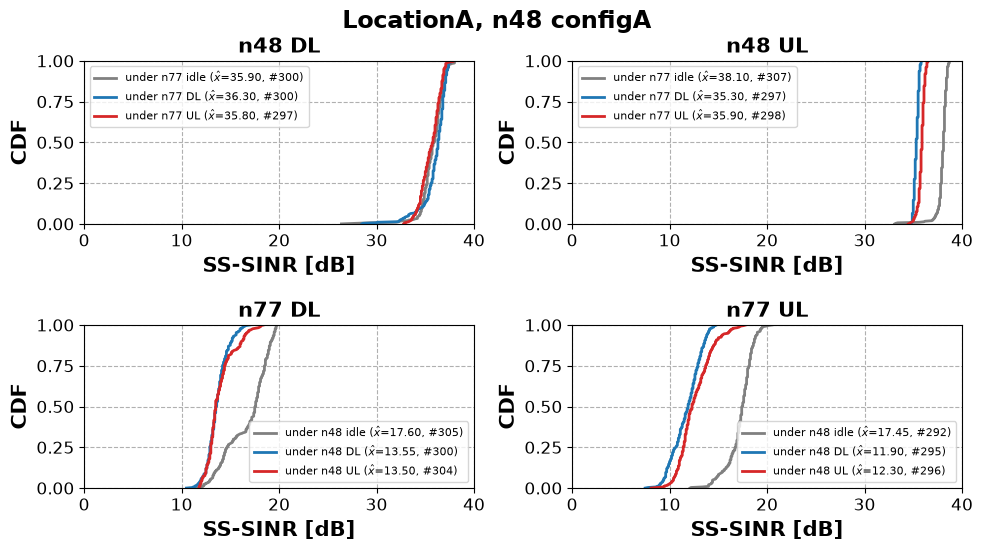

In [135]:
plot_sinr_cdf('004-012', 'LocationA, n48 configA')

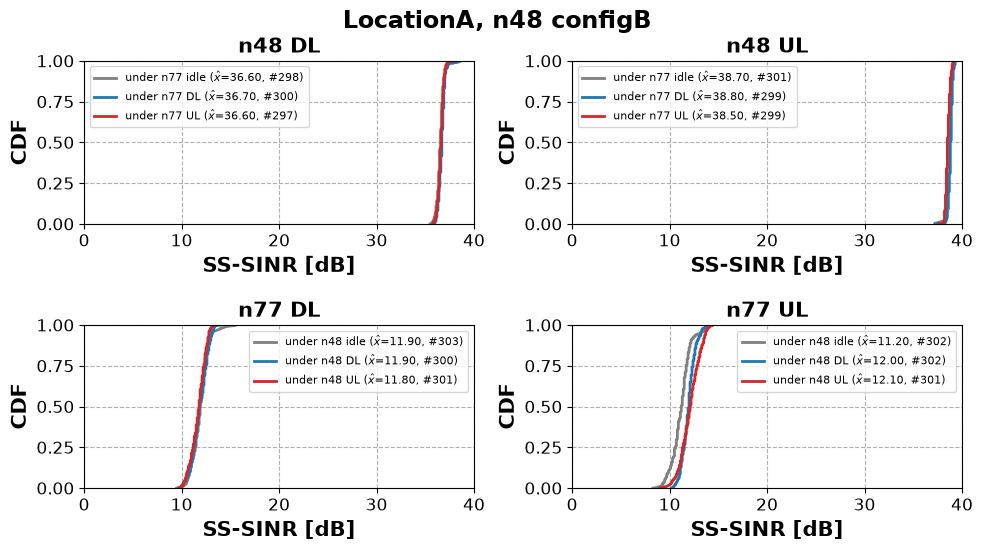

In [136]:
plot_sinr_cdf('049-057', 'LocationA, n48 configB')

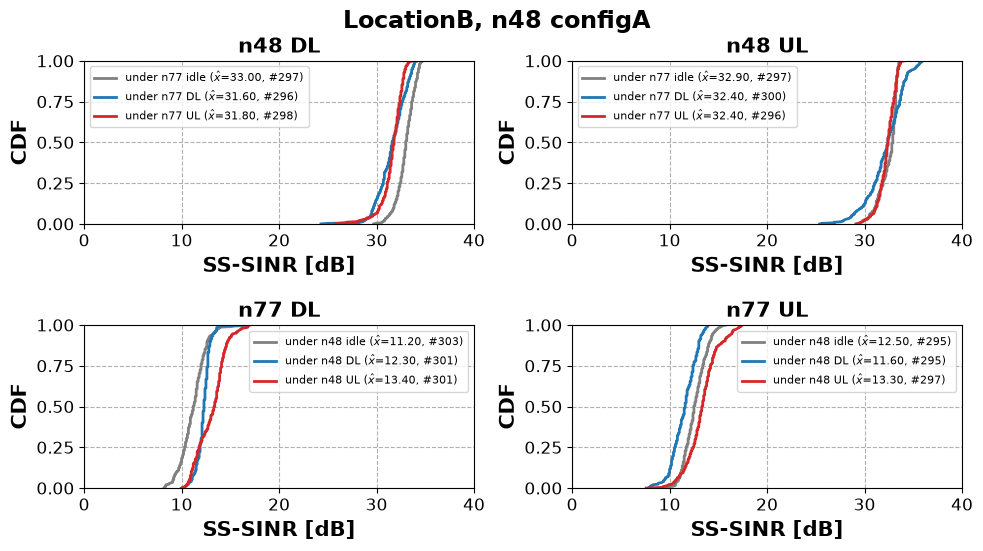

In [137]:
plot_sinr_cdf('013-021', 'LocationB, n48 configA')

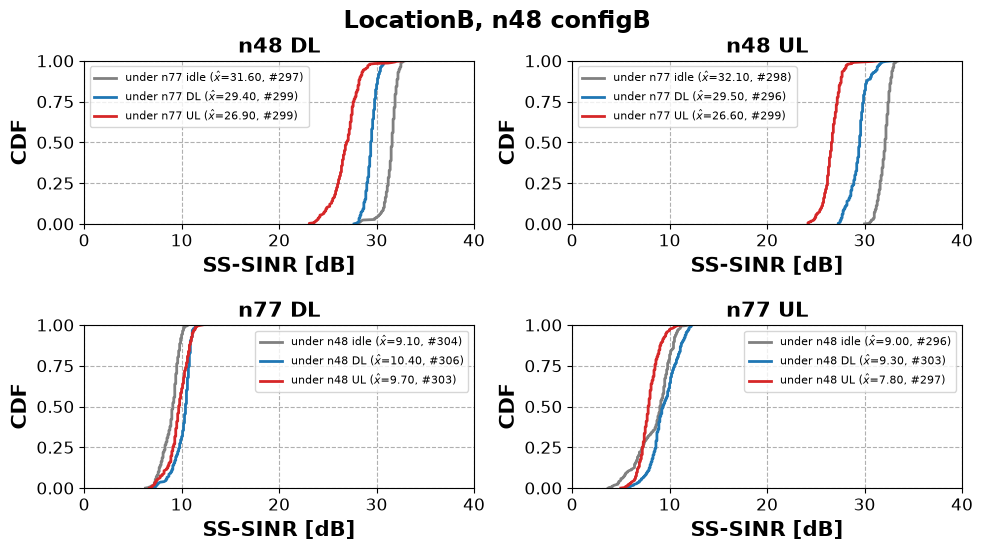

In [138]:
plot_sinr_cdf('058-066', 'LocationB, n48 configB')

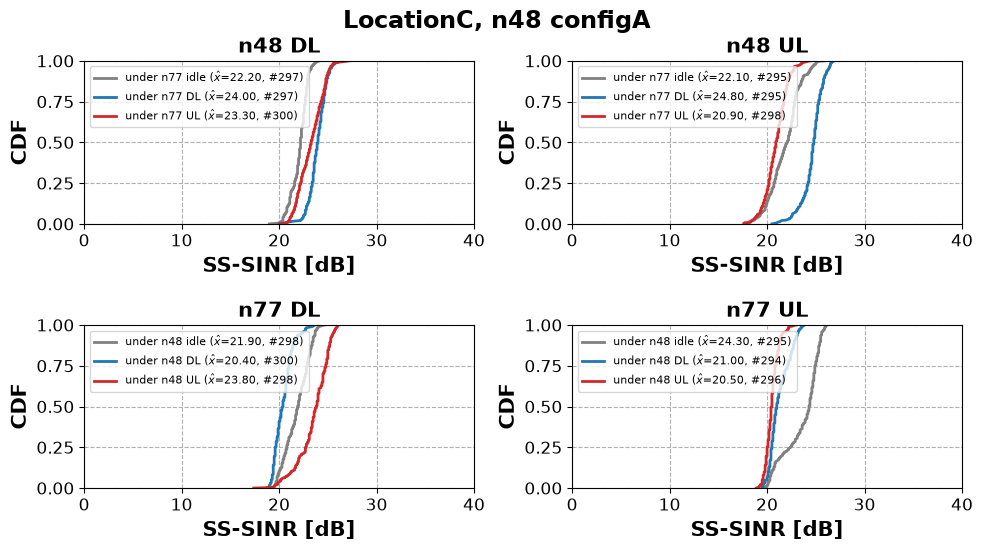

In [139]:
plot_sinr_cdf('022-030', 'LocationC, n48 configA')

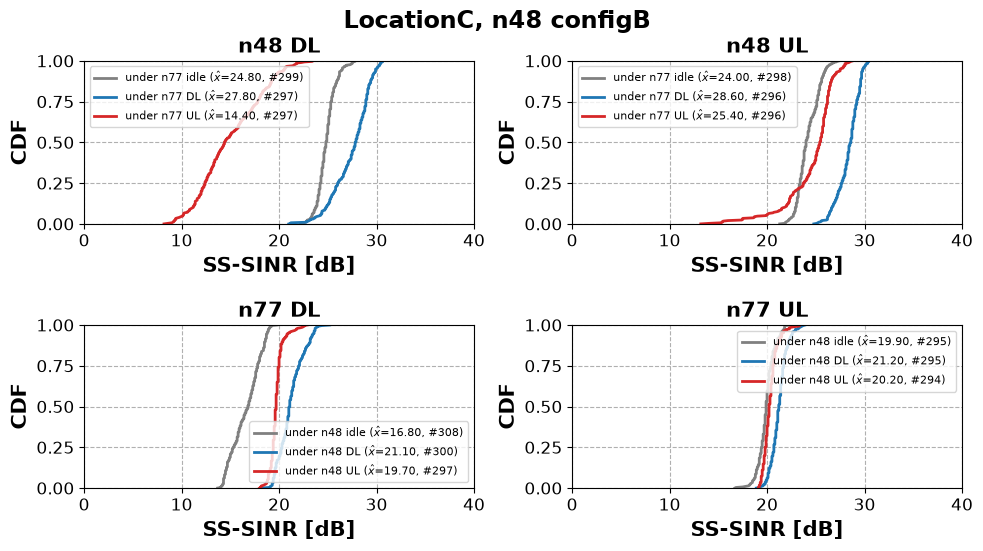

In [140]:
plot_sinr_cdf('067-075', 'LocationC, n48 configB')

# Debug: 0 Mbps

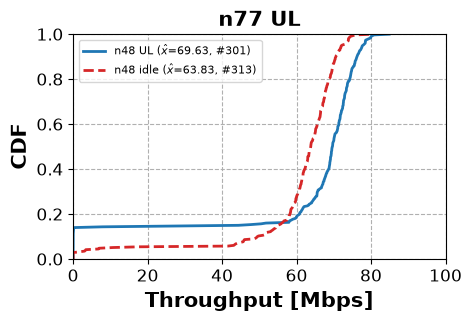

In [33]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[
    nrPusch['Collection'] == 'V_071',
    '5G NR Net PUSCH Throughput'
].dropna().sort_values() / 1e3

ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"n48 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[
    nrPusch['Collection'] == 'V_071_test',
    '5G NR Net PUSCH Throughput'
].dropna().sort_values() / 1e3

ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"n48 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="dashed", color="tab:red"
)

ax.set_title("n77 UL", fontsize=15, fontweight="bold")
ax.set_xlabel("Throughput [Mbps]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

In [ ]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPdsch.loc[nrPdsch['Collection'] == 'V_006', 'SS-RSRP'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPdsch.loc[nrPdsch['Collection'] == 'V_008', 'SS-RSRP'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPdsch.loc[nrPdsch['Collection'] == 'V_011', 'SS-RSRP'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_title("n77 UL, locA, configA - RSRP", fontsize=15, fontweight="bold")
ax.set_xlabel("SS-RSRP [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

# A

In [100]:
nrRadio.columns

Index(['Time', 'Database', 'Collection', 'Latitude', 'Longitude', 'Operator',
       'Serial Number', 'Model', 'RAN Configuration', 'Band Number',
       'PCI 5G NR', 'NR gNB-Id', 'Cell Id', 'SSB Index', 'SSB NR-ARFCN',
       'SS Block BW', 'DL NR-ARFCN', 'DL Point A NR-ARFCN', 'UL NR-ARFCN',
       'UL Point A Frequency', 'DL Bandwidth', 'UL Bandwidth',
       'DL Bandwidth Aggregated', 'UL Bandwidth Aggregated',
       'DL Subcarrier Spacing', 'Cell Type', 'SS-RSRP', 'SS-RSRQ', 'SS-SINR',
       'Timing Advance', 'Timing Advance Time', 'Test Name', 'Direction',
       'Test Status'],
      dtype='str')

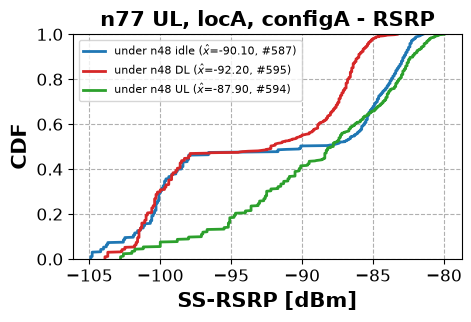

In [102]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrRadio.loc[nrRadio['Collection'] == 'V_006', 'SS-RSRP'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrRadio.loc[nrRadio['Collection'] == 'V_008', 'SS-RSRP'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrRadio.loc[nrRadio['Collection'] == 'V_011', 'SS-RSRP'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_title("n77 UL, locA, configA - RSRP", fontsize=15, fontweight="bold")
ax.set_xlabel("SS-RSRP [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

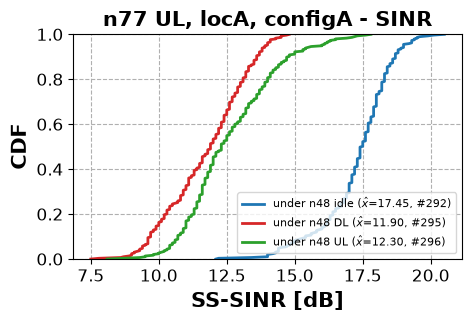

In [104]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrRadio.loc[nrRadio['Collection'] == 'V_006', 'SS-SINR'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrRadio.loc[nrRadio['Collection'] == 'V_008', 'SS-SINR'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrRadio.loc[nrRadio['Collection'] == 'V_011', 'SS-SINR'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_title("n77 UL, locA, configA - SINR", fontsize=15, fontweight="bold")
ax.set_xlabel("SS-SINR [dB]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

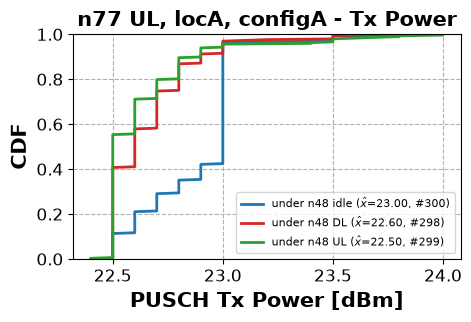

In [95]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_006', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_008', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_011', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_title("n77 UL, locA, configA - Tx Power", fontsize=15, fontweight="bold")
ax.set_xlabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

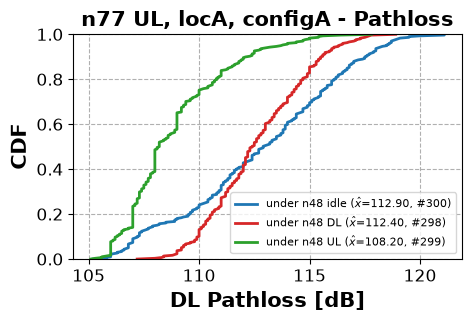

In [99]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_006', 'DL Pathloss'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_008', 'DL Pathloss'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_011', 'DL Pathloss'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_title("n77 UL, locA, configA - Pathloss", fontsize=15, fontweight="bold")
ax.set_xlabel("DL Pathloss [dB]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

In [97]:
nrPusch.columns

Index(['Time', 'Database', 'Collection', 'Latitude', 'Longitude', 'Operator',
       'Serial Number', 'Model', 'RAN Configuration', 'Band Number',
       'PCI 5G NR', 'SSB Index', 'UL NR-ARFCN', 'UL Point A Frequency',
       'UL Subcarrier Spacing', 'UL Bandwidth', 'UL Bandwidth Aggregated',
       'Cell Type', 'Max PUSCH Layers', 'Avg PUSCH Layers', 'PUSCH SCS',
       'Enabled256QAM', '5G NR Net PUSCH Throughput', 'PUSCH Avg RBs per Slot',
       'PUSCH RBs', 'MCS', 'PUSCH Used Slots', 'Bytes Transferred over PUSCH',
       'PUSCH Available Slots', 'PUSCH Slot Utilization',
       'PUSCH Avg RBs all Slots', 'PUSCH Tx Power', 'DL Pathloss',
       'PUSCH ReTx Rate', '1 Layer', '2 Layers', '3 Layers', '4 Layers',
       '5 Layers', '6 Layers', '7 Layers', '8 Layers', 'Num Slots',
       'Slot Pattern', 'Num Patterns', 'Pattern1 Periodicity',
       'Pattern1 UL Slots', 'Pattern1 UL Symbols', 'Pattern2 Periodicity',
       'Pattern2 UL Slots', 'Pattern2 UL Symbols', 'Num PUSCH TBs',
  

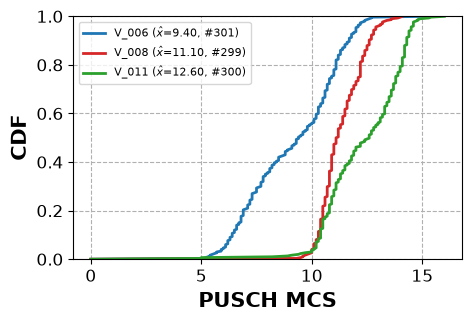

In [98]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_006', 'MCS'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"V_006 ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_008', 'MCS'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"V_008 ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_011', 'MCS'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"V_011 ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_xlabel("PUSCH MCS", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

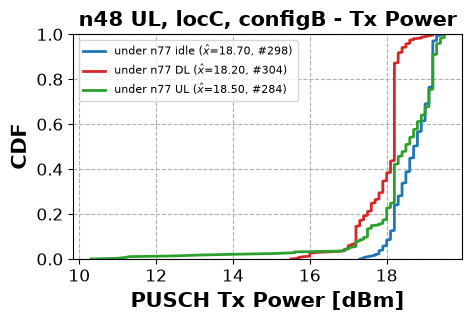

In [146]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_067', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n77 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_072', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n77 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_074', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n77 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_title("n48 UL, locC, configB - Tx Power", fontsize=15, fontweight="bold")
ax.set_xlabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

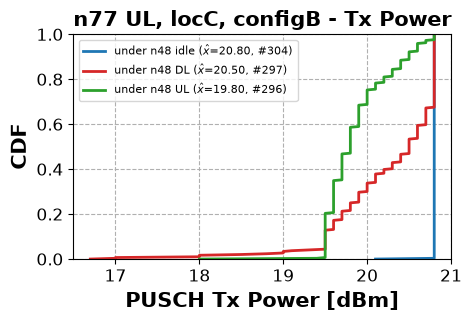

In [149]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_069', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_071', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_074', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_title("n77 UL, locC, configB - Tx Power", fontsize=15, fontweight="bold")
ax.set_xlabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

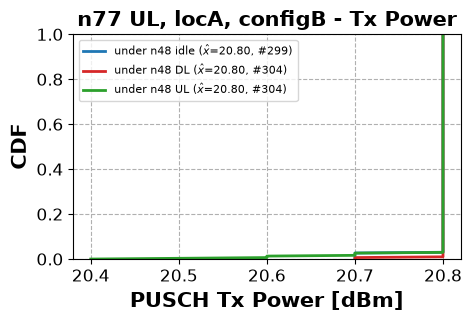

In [151]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_051', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_053', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'V_056', 'PUSCH Tx Power'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"under n48 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_title("n77 UL, locA, configB - Tx Power", fontsize=15, fontweight="bold")
ax.set_xlabel("PUSCH Tx Power [dBm]", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()